5.2

In [23]:
import numpy as np
filename = input('input name of file: ')
x, y = np.loadtxt(filename, unpack=True)
print("x: ",x)
print("y: ",y)
print("minimum of x", np.min(x))
print("minimum of y", np.min(y))
print("maximum of x", np.max(x))
print("maximum of y", np.max(y))
print("mean of x", np.mean(x))
print("mean of y", np.mean(y))
y_med = np.median(y)
y2 = (y - y_med)**2
print("y2: ", y2)

input name of file: ASCII
x:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
y:  [ 5. 10. 15. 20. 25. 30. 35. 40. 45. 50.]
minimum of x 1.0
minimum of y 5.0
maximum of x 10.0
maximum of y 50.0
mean of x 5.5
mean of y 27.5
y2:  [506.25 306.25 156.25  56.25   6.25   6.25  56.25 156.25 306.25 506.25]


5.6

In [19]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
x = np.concatenate((a, b))
print(x) 
print(x.shape)
print()

import numpy as np

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

y = np.concatenate((a, b))            #by default to axis=0
z = np.concatenate((a, b), axis=0)    #add rows together
w = np.concatenate((a, b), axis=1)    #add colums together
print(y)
print(y.shape)
print()
print(z)
print(z.shape)
print()
print(w)
print(w.shape)
#arrays q1 are in 1D, arrays q2 in 2D


[1 2 3 4 5 6]
(6,)

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
(4, 2)

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
(4, 2)

[[1 2 5 6]
 [3 4 7 8]]
(2, 4)


5.9

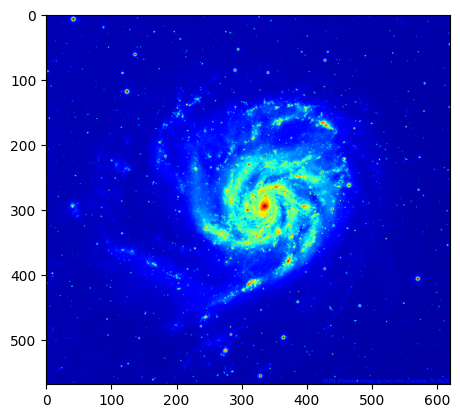

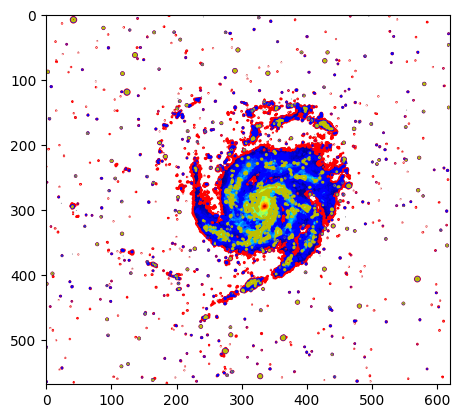

In [52]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np

#plot image 
x = imageio.imread("m101BW.jpg")
plt.imshow(x, cmap='jet')

#contour plot
fig = plt.figure()
frame = fig.add_subplot(1,1,1)
y = frame.contour(x, levels=np.percentile(x, [90,95,99]), colors=['r', 'b', 'y'])

#highest 10% intensity
z = np.percentile(x,90)
zz = np.where(x >= z, x, np.nan)
plt.imshow(zz, cmap='jet')
plt.show()

5.10

z-data: [0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]
max z: 0.0606
min z: 0.00482
sum z: 0.89154
mean z: 0.0222885
std z: 0.012699434544498428


Text(30, 0.04, 'max z: 0.0606\n min z: 0.00482\n sum z: 0.89154\n mean z: 0.0223\n std z: 0.0127')

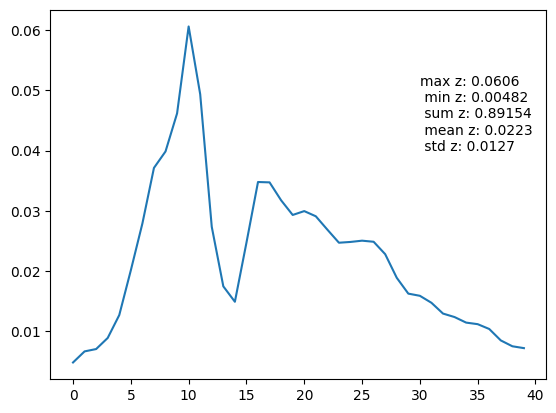

In [69]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt')
cube = data.reshape(40,50,70)  #turn data to 3D (z,y,x)

x_mid = 35
y_mid = 25

#z-profile in middle of xy-plane
z = cube[:, y_mid, x_mid]  #all z values along this axis at x_mid, y_mid

print('z-data:',z)
print('max z:', np.max(z))
print('min z:', np.min(z))
print('sum z:', np.sum(z))
print('mean z:', np.mean(z))
print('std z:', np.std(z))

plt.plot(z)
plt.text(30,0.04,f'max z: {np.max(z)}\n min z: {np.min(z)}\n sum z: {np.sum(z)}\n mean z: {np.mean(z):.4f}\n std z: {np.std(z):.4f}')

5.11

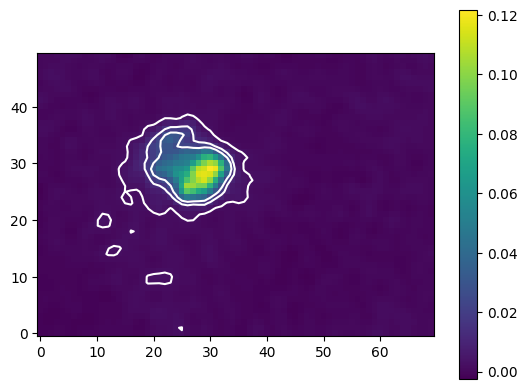

In [21]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt')
cube = data.reshape(40,50,70)  #turn data to 3D (z,y,x)

#extract the first plane\
first_plane = cube[0,:,:]  #first z plane for all x and y values

plt.imshow(first_plane, origin = 'lower')
plt.colorbar()

m = np.mean(first_plane)
sd = np.std(first_plane)

plt.contour(first_plane, levels = [m, m+sd, m+2*sd], colors='white')

5.12

In [32]:
import scipy.constants 

class Galaxy:    #class gives us the ablity to create objects, objects is an item created from the class
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    c = scipy.constants.c     #class variable so all objects from class can acces it
    
    def __init__(self, name, calciumHline=caH_0):  #initialize 
        self.name = name  #attribute, value associated with object, value obtained using a dot
        self.caH = calciumHline
    
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    
    def velocity(self):    #self refers to the current object, method is a function associated with object/class
        v = (self.redshift() * self.c)/1000
        return v

gal1 = Galaxy("NGC1832", 3994.7)
print('velocity of galaxy for test:',gal1.velocity())

velocity of galaxy for test: 1966.2458756852695


5.13

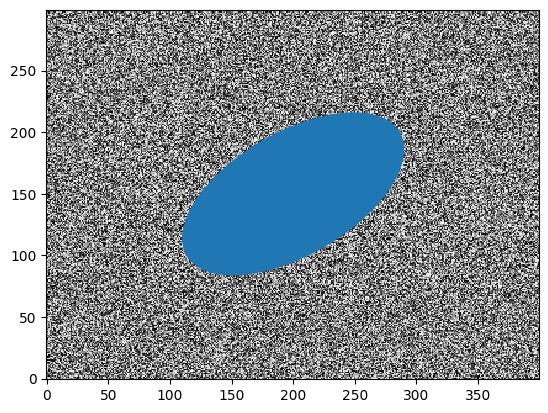

In [36]:
#dummy 2D
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

plt.imshow(data, interpolation='none', origin="lower", cmap='gray')

#origin at center of ellipse
x0 = Nx/2
y0 = Ny/2

#make ellipse
ellipse = Ellipse((x0, y0), width = 200, height = 100, angle = 30)
plt.gca().add_patch(ellipse) #add ellipse to image
plt.show()